In [18]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Make the plots look nice
sns.set_theme(style="whitegrid")

In [19]:
# Point this to your specific directory
directory_path = "runs/qwen35_9b_lora_newprompt/eval_results/"
json_files = [
    f for f in glob.glob(os.path.join(directory_path, "*.json")) 
    if os.path.basename(f) != "all_metrics.json"
]

data = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    
    if "base" in filename:
        step = 0
    elif "final" in filename:
        step = 99999 
    else:
        try:
            step = int(filename.split("-")[1].split(".")[0])
        except:
            step = -1

    with open(file_path, 'r', encoding='utf-8') as f:
        content = json.load(f)
        
    metrics = content.get("metrics", {})
    per_field_acc = metrics.get("per_field_accuracy", {})
    per_field_metrics = metrics.get("per_field_metrics", {})
    hazard_binary = metrics.get("hazard_present_binary", {})
    
    # Helper to safely get macro_f1
    def get_f1(field):
        return per_field_metrics.get(field, {}).get("macro_f1", 0)
    
    # Helper to sum False Positives across all classes in a field
    def get_fp(field):
        labels = per_field_metrics.get(field, {}).get("labels", {})
        return sum(label_info.get("fp", 0) for label_info in labels.values())

    row = {
        "checkpoint": filename.replace(".json", ""),
        "step": step,
        
        # --- OVERALL METRICS ---
        "exact_match_accuracy": metrics.get("exact_match_accuracy", 0),
        "hazard_f1": hazard_binary.get("f1", 0),
        "hazard_recall": hazard_binary.get("recall", 0), 
        "samples_per_sec": metrics.get("samples_per_sec", 0),
        
        # --- PER-FIELD ACCURACY ---
        "hazard_label_acc": per_field_acc.get("hazard_label", 0),
        "hazard_present_acc": per_field_acc.get("hazard_present", 0),
        "zone_relation_acc": per_field_acc.get("zone_relation", 0),
        "object_state_acc": per_field_acc.get("object_state", 0),
        "object_direction_acc": per_field_acc.get("object_direction", 0),
        
        # --- PER-FIELD MACRO F1 ---
        "hazard_label_f1": get_f1("hazard_label"),
        "hazard_present_f1": get_f1("hazard_present"),
        "zone_relation_f1": get_f1("zone_relation"),
        "object_state_f1": get_f1("object_state"),
        "object_direction_f1": get_f1("object_direction"),
        
        # --- PER-FIELD FALSE POSITIVES ---
        "hazard_label_fp": get_fp("hazard_label"),
        "hazard_present_fp": get_fp("hazard_present"),
        "zone_relation_fp": get_fp("zone_relation"),
        "object_state_fp": get_fp("object_state"),
        "object_direction_fp": get_fp("object_direction")
    }
    data.append(row)

# Create DataFrame and sort it chronologically
df = pd.DataFrame(data)
df = df.sort_values("step").reset_index(drop=True)

# Preview the first few rows
df.head()

,checkpoint,step,exact_match_accuracy,hazard_f1,hazard_recall,samples_per_sec,hazard_label_acc,hazard_present_acc,zone_relation_acc,object_state_acc,...,hazard_label_f1,hazard_present_f1,zone_relation_f1,object_state_f1,object_direction_f1,hazard_label_fp,hazard_present_fp,zone_relation_fp,object_state_fp,object_direction_fp
0,base_pretrained,0,0.1620,0.0000,0.0000,0.1583,0.7465,0.7465,0.2676,0.5915,...,0.4274,0.4274,0.2404,0.3867,0.3723,36,36,104,58,86
1,checkpoint-54,54,0.4014,0.0000,0.0000,0.1780,0.7465,0.7465,0.5915,0.6056,...,0.4274,0.4274,0.4335,0.4273,0.3818,36,36,58,56,68
2,checkpoint-108,108,0.5986,0.0000,0.0000,0.1811,0.7465,0.7465,0.7394,0.8873,...,0.4274,0.4274,0.6914,0.8595,0.4911,36,36,37,16,48
3,checkpoint-162,162,0.4296,0.0000,0.0000,0.1852,0.7465,0.7465,0.6479,0.7324,...,0.4274,0.4274,0.6130,0.7246,0.3755,36,36,50,38,74
4,checkpoint-216,216,0.6338,0.1053,0.0556,0.1808,0.7606,0.7606,0.8028,0.8803,...,0.4835,0.4835,0.7871,0.8332,0.6478,34,34,28,17,35


0 [-0.28598173  0.08969458]
13 [-0.60153536 -0.60117819]
1 [0.07606595 0.35690911]
14 [ 0.07935535 -0.32562652]
2 [0.47653202 0.28471601]
15 [-0.76546095  0.85418461]
3 [ 0.12139991 -0.79185587]
16 [-0.16023133 -0.21090763]
4 [ 0.26304977 -0.49478546]
17 [ 0.88231193 -0.18619294]
5 [0.92938566 0.95060725]
18 [ 0.15875388 -0.08168767]
6 [-0.34760335 -0.87762682]
19 [ 0.81331607 -0.59608742]
7 [-0.26704925  0.38574987]
20 [0.97668162 0.28026224]
8 [-0.86803749  0.10700889]
21 [-0.66014494 -0.07336885]
9 [0.05588576 0.62469049]
22 [-0.71343961  0.79036146]
35 [-0.45696743 -0.83654226]
61 [-0.05662385  0.23090415]
10 [-0.78618508  0.95281073]
23 [-0.31073475 -0.3836544 ]
11 [-0.30249583 -0.47330457]
24 [-0.73389996  0.52867669]
12 [0.36402732 0.90457981]
25 [-0.54692292  0.58003215]


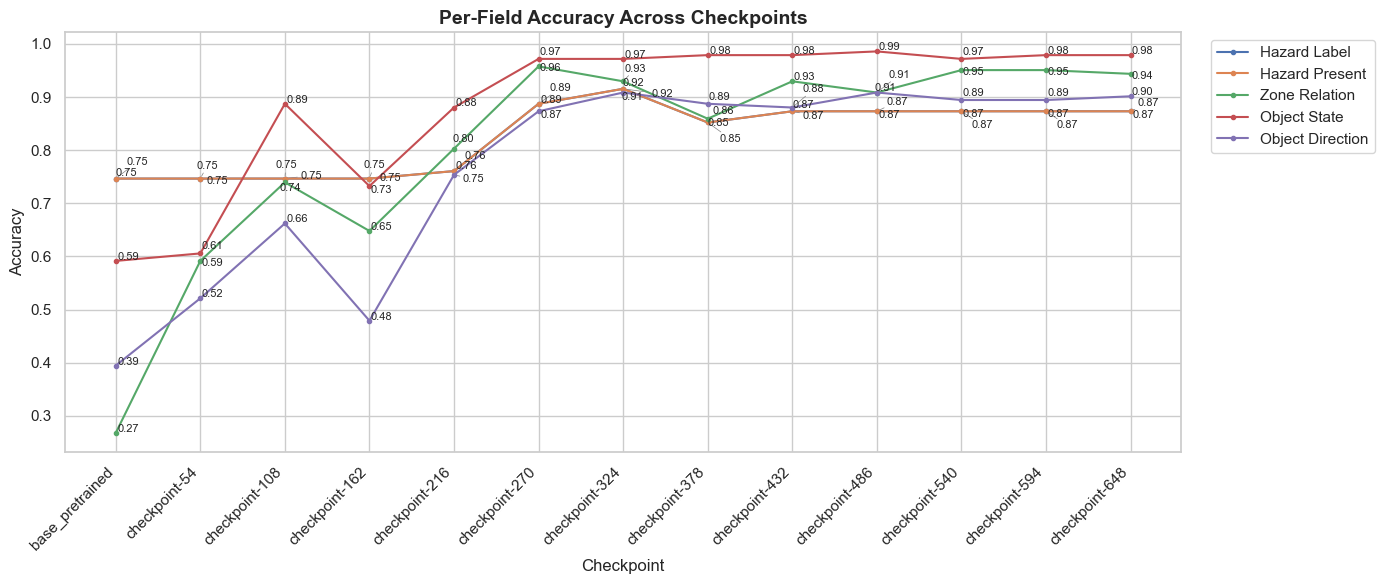

In [20]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ... (assuming df is defined above this snippet) ...

fields_to_plot = [
    "hazard_label_acc", 
    "hazard_present_acc", 
    "zone_relation_acc", 
    "object_state_acc", 
    "object_direction_acc"
]

plt.figure(figsize=(14, 6))

# 1. Create an empty list to store the text objects
texts = []

for field in fields_to_plot:
    # Remove the "_acc" for a cleaner legend label
    clean_label = field.replace("_acc", "").replace("_", " ").title()
    plt.plot(df["checkpoint"], df[field], marker='.', label=clean_label, linewidth=1.5)
    
    for x, y in zip(df["checkpoint"], df[field]):
        # 2. Append the text object to the list (removed ha and va since adjust_text handles positioning)
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# 3. Call adjust_text on the list of text objects
# arrowprops draws a small line from the text to the point if it gets moved far away
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title("Per-Field Accuracy Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Put the legend outside the chart so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [0.7755533 0.3559365]
13 [ 0.56792558 -0.45179737]
1 [-0.45238187  0.69417187]
14 [ 0.38258891 -0.3563766 ]
2 [-0.58246212  0.28931792]
15 [0.89805703 0.23706103]
3 [-0.55904858 -0.99092576]
16 [0.76615242 0.34577459]
4 [ 0.98323098 -0.11560782]
17 [-0.50288703 -0.19579626]
5 [ 0.70156053 -0.15515882]
18 [0.67828109 0.01927297]
6 [ 0.91347839 -0.60898412]
19 [-0.93065899  0.92679972]
7 [-0.57061969  0.07423534]
20 [0.59523686 0.31206597]
8 [ 0.13526077 -0.30939375]
21 [-0.77692858 -0.29704639]
9 [-0.17615955  0.54558326]
22 [-0.12885683 -0.7662686 ]
10 [-0.81608603  0.56252748]
23 [-0.79752839 -0.07004495]
11 [-0.45660167  0.73509989]
24 [ 0.01352331 -0.8670748 ]
12 [-0.91733091 -0.45736355]
25 [-0.36854374  0.51222877]


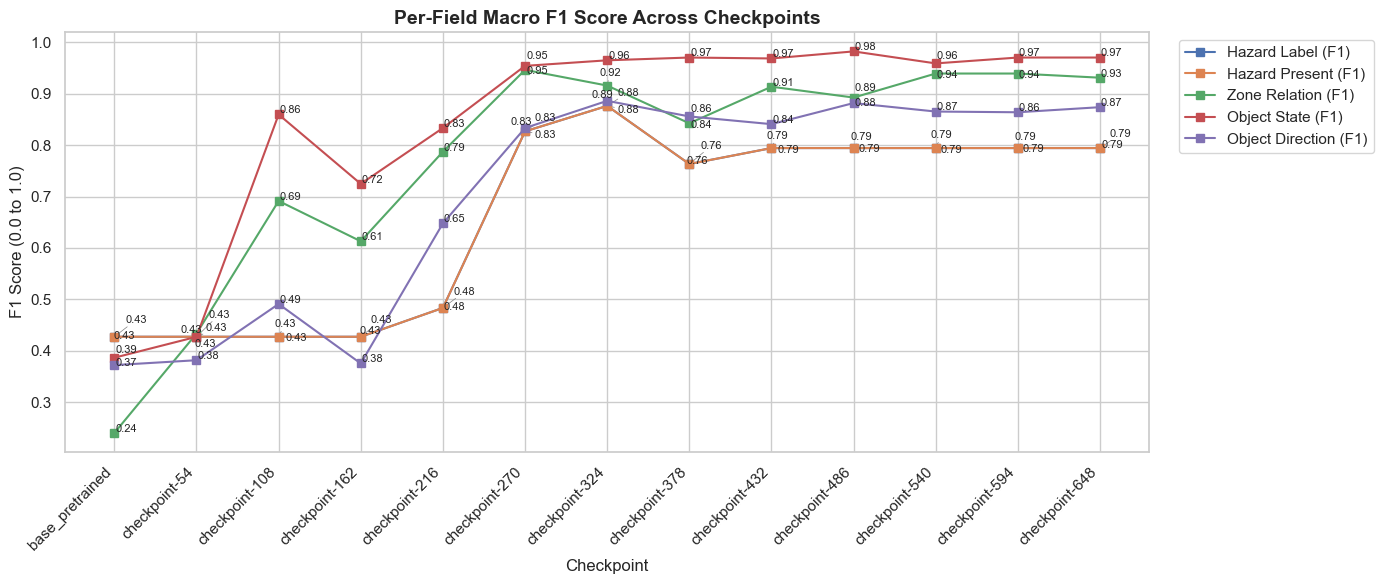

In [21]:
fields_to_plot_f1 = [
    "hazard_label_f1", 
    "hazard_present_f1", 
    "zone_relation_f1", 
    "object_state_f1", 
    "object_direction_f1"
]

plt.figure(figsize=(14, 6))

texts = [] # List to collect all the text objects

for field in fields_to_plot_f1:
    clean_label = field.replace("_f1", "").replace("_", " ").title() + " (F1)"
    plt.plot(df["checkpoint"], df[field], marker='s', label=clean_label, linewidth=1.5)
    
    # Create the text objects but don't finalize their positions yet
    for x, y in zip(df["checkpoint"], df[field]):
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# Let adjustText do the heavy lifting to prevent overlaps
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Macro F1 Score Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("F1 Score (0.0 to 1.0)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [ 0.78075124 -0.84214074]
13 [0.03962236 0.8756739 ]
1 [0.85890892 0.05791163]
14 [-0.20490517  0.96384067]
2 [-0.53807691  0.63608152]
15 [-0.19556517  0.78056122]
3 [-0.88587179 -0.72603799]
16 [-0.48751209  0.37136971]
4 [0.12449493 0.47697634]
17 [-0.57876992 -0.6510371 ]
5 [-0.90162671 -0.60735466]
18 [-0.51383855 -0.92774138]
6 [0.5328143  0.57533345]
19 [0.1394254  0.25213165]
7 [0.44329833 0.00406966]
20 [0.24908673 0.88946471]
8 [-0.99856469  0.61110119]
21 [-0.75424675  0.24588602]
35 [-0.59579962 -0.46870885]
61 [-0.26901247 -0.56669718]
9 [ 0.80665372 -0.35097182]
22 [-0.37044198  0.09850381]
10 [0.60575346 0.15643985]
23 [ 0.70325949 -0.4990667 ]
11 [-0.58055326  0.89036244]
24 [-0.34642644 -0.98305902]
12 [-0.54861692  0.88685619]
25 [ 0.69839734 -0.87712106]


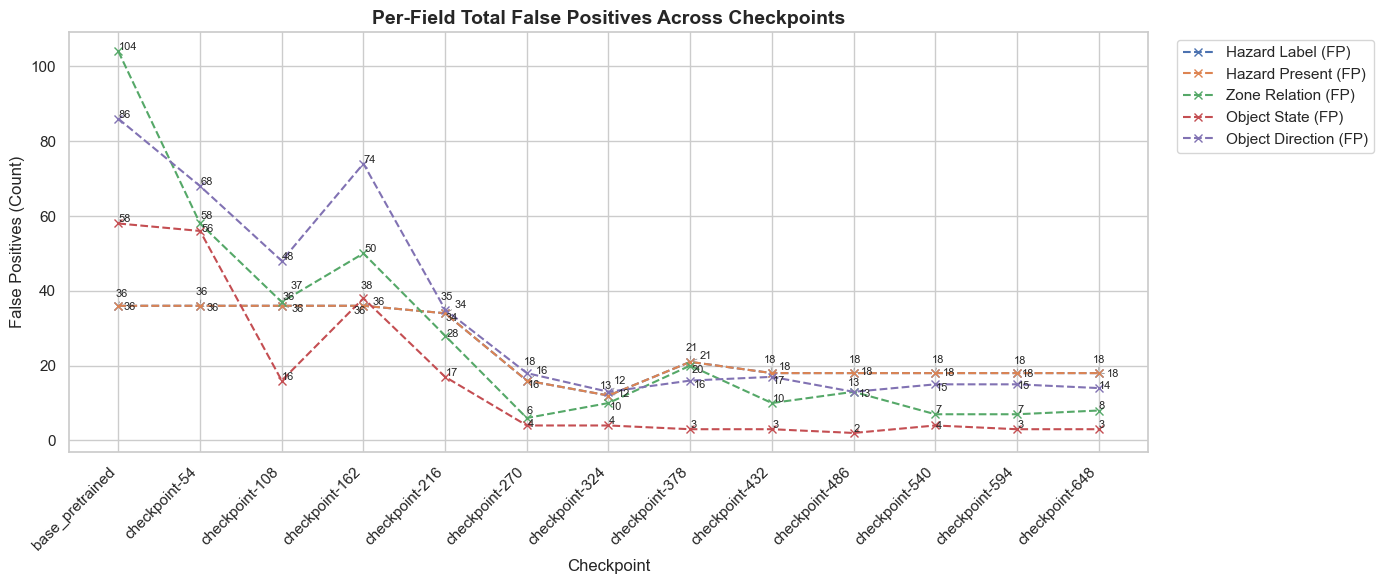

In [22]:
fields_to_plot_fp = [
    "hazard_label_fp", 
    "hazard_present_fp", 
    "zone_relation_fp", 
    "object_state_fp", 
    "object_direction_fp"
]

plt.figure(figsize=(14, 6))
texts = [] # List to collect text objects for automatic adjustment

for field in fields_to_plot_fp:
    # Formatting label for the legend
    clean_label = field.replace("_fp", "").replace("_", " ").title() + " (FP)"
    
    # Plotting with 'x' markers and dashed lines as requested
    plt.plot(df["checkpoint"], df[field], marker='x', label=clean_label, linewidth=1.5, linestyle='--')
    
    # Adding data labels to the list
    for x, y in zip(df["checkpoint"], df[field]):
        # Using int(y) for clean count labels
        texts.append(plt.text(x, y, f'{int(y)}', fontsize=8))

# This handles the magic of moving overlapping numbers
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Total False Positives Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("False Positives (Count)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Place legend outside to the right
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

In [26]:
import json

# Path to your evaluation JSON
file_path = "runs/qwen35_9b_lora_newprompt/eval_results/checkpoint-648.json"

def debug_mismatches_with_video(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = data.get("per_sample", [])
    
    # Updated headers to include Source Video ID
    print(f"{'Field':<18} | {'GT':<12} | {'Pred':<12} | {'Source Video ID':<45} | {'Sample ID'}")
    print("-" * 140)

    mismatch_count = 0

    for sample in samples:
        gt = sample.get("ground_truth", {})
        pred = sample.get("prediction_parsed", {})
        matches = sample.get("field_matches", {})
        
        # Pulling source_video_id from the 'meta' dictionary
        meta = sample.get("meta", {})
        video_id = meta.get("source_video_id", "N/A")
        sample_id = sample.get("sample_id", "Unknown")

        # Check every field for a False match
        for field, is_match in matches.items():
            if is_match is False:
                gt_val = gt.get(field, "N/A")
                pred_val = pred.get(field, "N/A")
                
                # Print the mismatch with the Video ID
                print(f"{field:<18} | {str(gt_val):<12} | {str(pred_val):<12} | {str(video_id):<45} | {sample_id}")
                mismatch_count += 1

    print("-" * 140)
    print(f"Total Mismatches Found: {mismatch_count}")

debug_mismatches_with_video(file_path)

Field              | GT           | Pred         | Source Video ID                               | Sample ID
--------------------------------------------------------------------------------------------------------------------------------------------
hazard_label       | unsafe_forklift_approach | no_hazard    | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
hazard_present     | yes          | no           | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
object_direction   | towards      | away         | 동일유리02_S20250716113905_E20250716114050        | 동일유리02_S20250716113905_E20250716114050__000065000_000070000
hazard_label       | unsafe_forklift_approach | no_hazard    | 금진Camera05_S20251213082156_E20251213083037    | 금진Camera05_S20251213082156_E20251213083037__000004000_000009000
hazard_present     | yes          | no           | 금진Camera05_S20251213082156_E2025121